# Stylized Facts of Financial Markets

Stylized facts là các đặc điểm thống kê lặp lại trong dữ liệu tài chính
ở nhiều thị trường và nhiều giai đoạn khác nhau.

Điều đặc biệt là các đặc điểm này xuất hiện:

- ở cổ phiếu
- ở futures
- ở forex
- ở crypto

Điều này cho thấy chúng không phải là ngẫu nhiên mà là **tính chất cấu trúc của thị trường**.

Trong notebook này chúng ta sẽ xem xét một số stylized facts cơ bản:

- phân phối return có **đuôi dày (fat tails)**
- return gần như **không có autocorrelation tuyến tính**
- **volatility clustering**

Mục tiêu của notebook này là quan sát các đặc điểm thống kê,
chưa giải thích cơ chế tạo ra chúng.

## Import Libraries

Chúng ta sẽ sử dụng numpy để tạo dữ liệu mô phỏng
và matplotlib để trực quan hóa.

Các hàm tính toán stylized facts được đặt trong module
`stylized_facts.py`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.metrics import (
    returns,
    kurtosis,
    tail_ratio,
    return_autocorrelation,
    volatility_clustering,
)

## Generate Synthetic Price Series

Để minh họa các khái niệm cơ bản,
chúng ta tạo một chuỗi giá đơn giản bằng **random walk**.

Giả định:

- mỗi bước thời gian có return ngẫu nhiên
- return tuân theo phân phối chuẩn
- giá được tạo bằng cách tích lũy các return

Đây là mô hình đơn giản nhất của biến động giá.

In [3]:
np.random.seed(0)

n = 5000

sim_returns = np.random.normal(0, 0.01, n)

prices = 100 * np.cumprod(1 + sim_returns)

prices[:10]

array([101.76405235, 102.17126854, 103.17125755, 105.48321524,
       107.45317546, 106.40305934, 107.41398249, 107.25140368,
       107.14070001, 107.58061812])

## Interpretation of Generated Price Series

Kết quả hiển thị là **10 giá trị đầu tiên** của chuỗi giá được tạo từ mô hình random walk:

$$
P_t = P_{t-1}(1 + r_t)
$$

trong đó:

$$
r_t \sim \mathcal{N}(0, \sigma^2)
$$

Điều này có nghĩa là mỗi bước thời gian giá thay đổi theo một **return ngẫu nhiên** có phân phối chuẩn.

Từ kết quả có thể quan sát một số đặc điểm:

- Giá **dao động quanh mức ban đầu (100)** nhưng không có xu hướng rõ ràng.
- Biến động giá là **liên tục và ngẫu nhiên**, mỗi bước phụ thuộc vào return mới được sinh ra.
- Mức biến động tương đối nhỏ vì độ lệch chuẩn của return được đặt là $0.01$.

Chuỗi giá này là một ví dụ của **Gaussian random walk**, thường được sử dụng làm **baseline model** trong tài chính.

Tuy nhiên, dữ liệu thị trường thực tế thường **không tuân theo mô hình đơn giản này**.
Các phần tiếp theo của notebook sẽ kiểm tra các đặc điểm thống kê (stylized facts) để thấy sự khác biệt giữa mô hình Gaussian và dữ liệu tài chính.

## Price Series

Chuỗi giá được tạo từ một **random walk với return Gaussian**.

Giả sử mỗi bước thời gian có return:

$$
r_t \sim \mathcal{N}(0, \sigma^2)
$$

Giá được xây dựng bằng cách tích lũy return:

$$
P_t = P_{t-1}(1 + r_t)
$$

Trong đó:

- $P_t$ : giá tại thời điểm $t$
- $r_t$ : return tại thời điểm $t$

Chuỗi giá vì vậy là **tích của các return ngẫu nhiên**.

Trong mô hình này:

- return **độc lập**
- return **phân phối chuẩn**
- không có cấu trúc thị trường

Đây là mô hình đơn giản nhất để mô tả biến động giá và thường được gọi là **Gaussian random walk**.

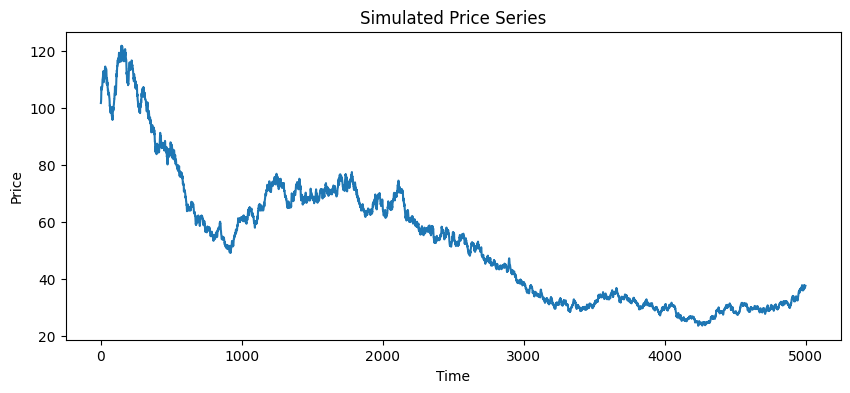

In [4]:
plt.figure(figsize=(10,4))
plt.plot(prices)
plt.title("Simulated Price Series")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

## Interpretation of Simulated Price Path

Biểu đồ trên thể hiện chuỗi giá được tạo từ **Gaussian random walk**.
Giá được xây dựng từ các return ngẫu nhiên:

$$
P_t = P_{t-1}(1 + r_t)
$$

trong đó:

$$
r_t \sim \mathcal{N}(0, \sigma^2)
$$

### Observations

Từ đồ thị có thể quan sát một số đặc điểm:

- Chuỗi giá **dao động liên tục theo thời gian** nhưng không có cấu trúc rõ ràng.
- Giá có thể **tăng hoặc giảm trong các giai đoạn dài** chỉ do tích lũy của các biến động ngẫu nhiên.
- Biến động có vẻ **khá mượt và ổn định**, không xuất hiện các cú nhảy cực lớn.

Một điểm quan trọng là dù return có trung bình bằng 0, chuỗi giá vẫn có thể **trôi xa khỏi mức ban đầu** theo thời gian.

Điều này xảy ra vì giá là **tích lũy của các biến động ngẫu nhiên**.

### Interpretation

Mô hình random walk giả định:

- return **độc lập**
- return **phân phối chuẩn**
- không có cấu trúc thị trường

Do đó price path trông **giống chuyển động ngẫu nhiên (diffusion process)**.

### Implication

Mặc dù mô hình này đơn giản và thường được dùng làm baseline,
dữ liệu thị trường thực tế thường có những đặc điểm khác:

- phân phối return **có đuôi dày**
- volatility **cluster theo thời gian**
- order flow **có tính phụ thuộc dài hạn**

Các phần tiếp theo của notebook sẽ kiểm tra các đặc điểm thống kê này.

## Return Distribution

Trong tài chính, phân tích thống kê thường được thực hiện trên **return** thay vì giá.

Return được định nghĩa:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Trong đó:

- $P_t$ : giá tại thời điểm $t$
- $P_{t-1}$ : giá tại thời điểm trước đó

Return có một số ưu điểm:

- cho phép so sánh biến động giữa các tài sản có mức giá khác nhau
- chuỗi return thường **stationary** (phân phối ổn định theo thời gian)
- nhiều mô hình thống kê được xây dựng trực tiếp trên return

Vì vậy hầu hết phân tích định lượng trong tài chính đều bắt đầu từ **return series**.

In [5]:
r = returns(prices)

r[:10]

array([ 0.00400157,  0.00978738,  0.02240893,  0.01867558, -0.00977278,
        0.00950088, -0.00151357, -0.00103219,  0.00410599,  0.00144044])

## Interpretation of Return Series

Kết quả hiển thị là **10 giá trị đầu tiên của chuỗi return** các giá trị này biểu diễn **tỷ lệ thay đổi giá giữa hai thời điểm liên tiếp**.

Return được định nghĩa:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

trong đó:

- $P_t$ : giá tại thời điểm $t$
- $P_{t-1}$ : giá tại thời điểm trước đó

### Observations

Từ các giá trị return có thể quan sát:

- Return dao động quanh **0**, phù hợp với giả định $E[r_t] = 0$.
- Các giá trị thường nằm trong khoảng **±1–2%**, do độ lệch chuẩn được đặt là $\sigma = 0.01$.
- Return có thể **dương hoặc âm**, tương ứng với tăng hoặc giảm giá.

### Interpretation

Trong mô hình hiện tại:

$$
r_t \sim \mathcal{N}(0, \sigma^2)
$$

nghĩa là return được sinh ra từ **phân phối chuẩn với trung bình 0**.

Điều này dẫn tới một số tính chất:

- return **độc lập theo thời gian**
- return **không có autocorrelation**
- phân phối return **đối xứng quanh 0**

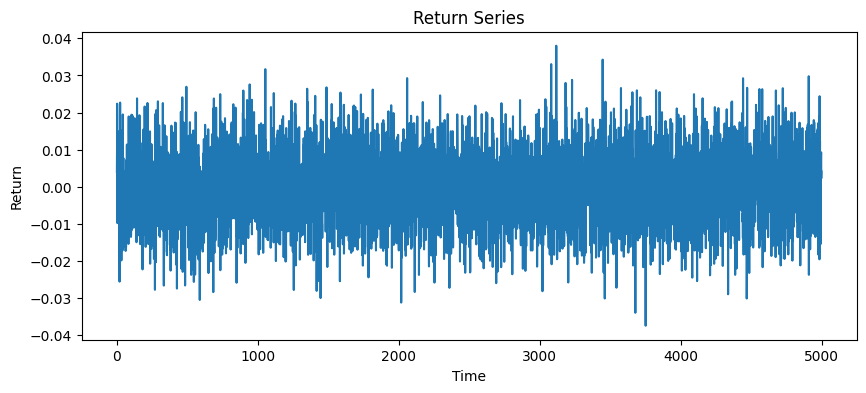

In [11]:
plt.figure(figsize=(10,4))
plt.plot(r)
plt.title("Return Series")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

## Interpretation of Return Series

Biểu đồ trên thể hiện **chuỗi return theo thời gian**.
Return được định nghĩa:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

trong đó:

- $P_t$ : giá tại thời điểm $t$
- $P_{t-1}$ : giá tại thời điểm trước đó

### Observations

Từ biểu đồ có thể quan sát một số đặc điểm:

- Return dao động quanh **0**, cho thấy không có xu hướng tăng hoặc giảm dài hạn.
- Phần lớn return nằm trong khoảng **±1–2%**, phù hợp với độ lệch chuẩn $\sigma = 0.01$ đã sử dụng trong mô phỏng.
- Các biến động lớn (spikes) xuất hiện rải rác nhưng không theo cấu trúc rõ ràng.
- Mức độ biến động nhìn chung **khá ổn định theo thời gian**.

Chuỗi return vì vậy trông giống **noise ngẫu nhiên**.

### Interpretation

Trong mô hình hiện tại:

$$
r_t \sim \mathcal{N}(0, \sigma^2)
$$

nghĩa là return được sinh ra từ **phân phối chuẩn với trung bình bằng 0**.

Do đó:

- return **độc lập theo thời gian**
- return **không có autocorrelation**
- variance của return **ổn định**

Những đặc điểm này phù hợp với giả định của **Gaussian random walk**.

### Implication

Trong dữ liệu thị trường thực tế, chuỗi return thường **không hoàn toàn giống noise Gaussian**.

Các đặc điểm thường quan sát được gồm:

- **fat tails** (các biến động cực lớn xảy ra thường xuyên hơn Gaussian)
- **volatility clustering** (giai đoạn biến động mạnh thường đi cùng nhau)
- **heteroskedasticity** (độ biến động thay đổi theo thời gian)

Các phần tiếp theo của notebook sẽ kiểm tra những đặc điểm thống kê này.

## Fat Tails

Một stylized fact quan trọng của thị trường tài chính là **phân phối return có đuôi dày (fat tails)**.

Điều này có nghĩa:

các biến động lớn xảy ra **thường xuyên hơn** so với dự đoán của phân phối chuẩn.

Để đo mức độ đuôi dày, ta sử dụng **kurtosis**.

Kurtosis được định nghĩa:

$$
K = E\left[\left(\frac{r - \mu}{\sigma}\right)^4\right]
$$

Trong đó:

- $\mu$ : trung bình của return
- $\sigma$ : độ lệch chuẩn

Đối với phân phối chuẩn:

$$
K = 3
$$

Nếu:

$$
K > 3
$$

phân phối được gọi là **leptokurtic** (đuôi dày).

Trong thị trường tài chính thực tế, kurtosis thường **lớn hơn nhiều so với 3**.

Điều này cho thấy:

**các sự kiện cực đoan (crash, spike) xảy ra thường xuyên hơn Gaussian dự đoán.**

In [6]:
print("kurtosis:", kurtosis(r))
print("tail ratio:", tail_ratio(r))

kurtosis: 2.944388397791374
tail ratio: 0.9929373304724233


## Interpretation of Tail Statistics

Để đánh giá hình dạng của phân phối return, ta sử dụng hai chỉ số:

- **kurtosis**
- **tail ratio**

### Kurtosis

Kurtosis đo mức độ "nặng" của hai đuôi phân phối.

Kết quả từ dữ liệu mô phỏng:
$$
kurtosis = 2.94
$$

Giá trị này **rất gần 3**, cho thấy phân phối return trong mô phỏng gần giống phân phối chuẩn.

Điều này phù hợp với mô hình đã sử dụng, vì return được sinh ra từ:

$$
r_t \sim \mathcal{N}(0,\sigma^2)
$$

### Tail Ratio

Tail ratio so sánh độ lớn của hai đuôi phân phối:

$$
\text{Tail Ratio} =
\left|
\frac{Q_{0.95}}{Q_{0.05}}
\right|
$$

trong đó:

- $Q_{0.95}$ : quantile 95%
- $Q_{0.05}$ : quantile 5%

Nếu phân phối đối xứng quanh 0, ta kỳ vọng:

$$
\text{Tail Ratio} \approx 1
$$

Kết quả từ dữ liệu:
$$
tail ratio = 0.99
$$


Giá trị này rất gần 1, cho thấy phân phối return **gần đối xứng**.

### Implication

Hai kết quả trên cho thấy:

- phân phối return gần **Gaussian**
- không có **đuôi dày rõ rệt**

Điều này là hợp lý vì dữ liệu được tạo từ **Gaussian random walk**.

Trong dữ liệu thị trường thực tế, kurtosis thường **lớn hơn nhiều so với 3**, phản ánh sự xuất hiện thường xuyên của các biến động cực đoan.

Hiện tượng này chính là **fat tails**, một stylized fact quan trọng của thị trường tài chính.

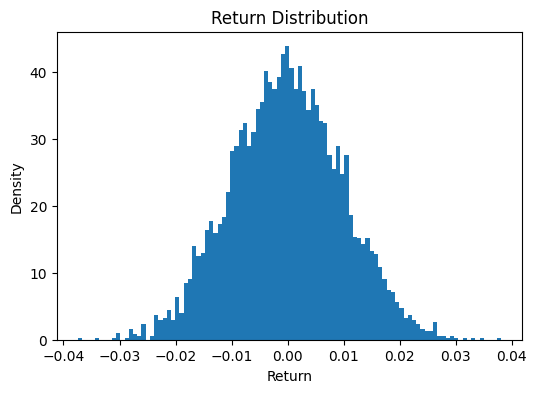

In [7]:
plt.figure(figsize=(6,4))
plt.hist(r, bins=100, density=True)
plt.title("Return Distribution")
plt.xlabel("Return")
plt.ylabel("Density")
plt.show()

## Interpretation of Return Distribution

Biểu đồ trên là **histogram của chuỗi return**.
Histogram cho phép quan sát hình dạng của phân phối xác suất.

### Observations

Từ biểu đồ có thể thấy:

- Phân phối có dạng **chuông (bell-shaped)**.
- Phần lớn return tập trung quanh **0**.
- Xác suất của các biến động lớn giảm dần khi $|r|$ tăng.
- Phân phối **gần đối xứng** quanh 0.

Điều này phù hợp với kết quả thống kê đã tính:

- kurtosis ≈ 2.94
- tail ratio ≈ 0.99

Hai giá trị này cho thấy phân phối return **gần giống phân phối chuẩn**.

### Gaussian Benchmark

Nếu return tuân theo phân phối chuẩn:

$$
r_t \sim \mathcal{N}(0, \sigma^2)
$$

thì phân phối xác suất có dạng:

$$
f(r) =
\frac{1}{\sigma \sqrt{2\pi}}
\exp\left(
-\frac{r^2}{2\sigma^2}
\right)
$$

Histogram trong mô phỏng có hình dạng rất gần với dạng lý thuyết này.

### Implication

Kết quả này là điều **kỳ vọng**, vì chuỗi return được tạo trực tiếp từ phân phối Gaussian.

Tuy nhiên trong dữ liệu thị trường thực tế, histogram return thường khác đáng kể:

- hai đuôi phân phối **dày hơn**
- các biến động cực đoan xảy ra **thường xuyên hơn Gaussian dự đoán**

Điều này dẫn tới kurtosis:

$$
K \gg 3
$$

Hiện tượng này được gọi là **fat tails** và là một stylized fact quan trọng của thị trường tài chính.

## Return Autocorrelation

Autocorrelation đo mức độ phụ thuộc giữa các giá trị trong chuỗi thời gian.

Autocorrelation của return tại lag $k$ được định nghĩa:

$$
\rho_k =
\frac{E[(r_t - \mu)(r_{t-k} - \mu)]}{\sigma^2}
$$

Trong đó:

- $\rho_k$ : autocorrelation tại lag $k$
- $r_t$ : return tại thời điểm $t$

Một stylized fact nổi tiếng của thị trường tài chính:

$$
\rho_k \approx 0
$$

đối với các lag nhỏ.

In [8]:
print("return autocorrelation:", return_autocorrelation(r))

return autocorrelation: 0.009162008740004831


## Interpretation of Return Autocorrelation

Autocorrelation đo mức độ phụ thuộc giữa các giá trị trong một chuỗi thời gian.

Autocorrelation của return tại lag $k$ được định nghĩa:

$$
\rho_k =
\frac{E[(r_t - \mu)(r_{t-k} - \mu)]}{\sigma^2}
$$

trong đó:

- $r_t$ : return tại thời điểm $t$
- $\mu$ : trung bình của return
- $\sigma^2$ : variance của return

Nếu:

$$
\rho_k = 0
$$

thì return **không có tương quan tuyến tính theo thời gian**.

### Observations

Kết quả từ mô phỏng:

$$
return autocorrelation = 0.009
$$


Giá trị này **rất gần 0**, cho thấy return gần như không có autocorrelation.

Điều này phù hợp với giả định của mô hình:

$$
r_t \sim \mathcal{N}(0, \sigma^2)
$$

trong đó các return được sinh ra **độc lập theo thời gian**.

### Interpretation

Khi return không có autocorrelation, giá trong ngắn hạn **khó dự đoán bằng mô hình tuyến tính đơn giản**.

Điều này thường được liên hệ với khái niệm:

**weak-form market efficiency**
(thị trường hiệu quả dạng yếu).

Theo giả thuyết này, thông tin trong giá quá khứ **không thể được sử dụng để dự đoán lợi nhuận tương lai một cách hệ thống**.

### Implication

Một stylized fact nổi tiếng của dữ liệu tài chính là:

- return thường có **autocorrelation rất nhỏ**
- nhưng **volatility lại có autocorrelation mạnh**

Điều này có nghĩa:

$$
Corr(r_t, r_{t-k}) \approx 0
$$

nhưng

$$
Corr(|r_t|, |r_{t-k}|) > 0
$$

Hiện tượng này sẽ được kiểm tra trong phần tiếp theo của notebook.

## Volatility Clustering

Mặc dù return gần như không có autocorrelation,
độ lớn của return lại có cấu trúc rõ ràng.

Cụ thể:

- Các giai đoạn biến động mạnh thường đi cùng các giai đoạn biến động mạnh khác.
- Hiện tượng này được gọi là **volatility clustering**.
- Một cách đo lường đơn giản là autocorrelation của:

$$
|r_t|
$$

hoặc

$$
r_t^2
$$

In [9]:
print("volatility clustering:", volatility_clustering(r))

volatility clustering: -0.018162509213806338


## Interpretation of Volatility Clustering

Volatility clustering mô tả hiện tượng trong đó
các giai đoạn biến động mạnh thường đi cùng các giai đoạn biến động mạnh khác.

Một cách đo lường đơn giản là autocorrelation của **absolute returns**:

$$
Corr(|r_t|, |r_{t-k}|)
$$

Nếu giá trị này dương và đáng kể,
ta nói rằng **volatility có xu hướng cluster theo thời gian**.

### Observations

Kết quả từ dữ liệu mô phỏng:
$$
volatility clustering = -0.018
$$


Giá trị này rất gần **0** và thậm chí hơi âm.

Điều này cho thấy:

- độ biến động của return **không có cấu trúc theo thời gian**
- các giai đoạn biến động lớn **không có xu hướng đi cùng nhau**

### Interpretation

Kết quả này phù hợp với mô hình đã sử dụng:

$$
r_t \sim \mathcal{N}(0,\sigma^2)
$$

Trong Gaussian random walk:

- return **độc lập theo thời gian**
- variance **không thay đổi**

Do đó:

$$
Corr(|r_t|, |r_{t-k}|) \approx 0
$$

### Implication

Trong dữ liệu thị trường thực tế,
volatility clustering là một stylized fact rất mạnh.

Thường quan sát:

$$
Corr(|r_t|, |r_{t-k}|) > 0
$$

Điều này có nghĩa:

- các giai đoạn biến động mạnh thường **kéo dài**
- thị trường có các **regime volatility**

Các mô hình thống kê như:

- ARCH
- GARCH

được phát triển để mô tả chính hiện tượng này.

Gaussian random walk không thể tái tạo đặc điểm này,
điều này cho thấy cần những cơ chế thị trường phức tạp hơn.

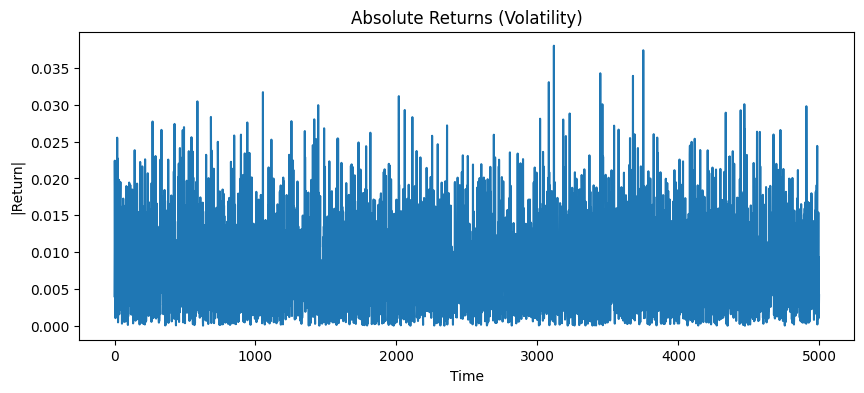

In [10]:
plt.figure(figsize=(10,4))
plt.plot(np.abs(r))
plt.title("Absolute Returns (Volatility)")
plt.xlabel("Time")
plt.ylabel("|Return|")
plt.show()

## Interpretation of Absolute Returns

Biểu đồ trên thể hiện **absolute returns**:

$$
|r_t|
$$

Absolute return thường được dùng như một **proxy cho volatility**
(volatility proxy: đại lượng xấp xỉ độ biến động).

### Observations

Từ biểu đồ có thể quan sát:

- Giá trị $|r_t|$ dao động quanh một mức tương đối ổn định.
- Các spike lớn xuất hiện **ngẫu nhiên và rải rác** theo thời gian.
- Không thấy các giai đoạn mà volatility duy trì ở mức cao trong thời gian dài.

Điều này cho thấy mức biến động **không có cấu trúc theo thời gian rõ ràng**.

### Interpretation

Trong mô hình hiện tại:

$$
r_t \sim \mathcal{N}(0,\sigma^2)
$$

với $\sigma$ không đổi theo thời gian.

Do đó:

- variance của return **ổn định**
- volatility **không có persistence**

Điều này dẫn đến:

$$
Corr(|r_t|, |r_{t-k}|) \approx 0
$$

kết quả đã quan sát trong phép đo volatility clustering.

### Implication

Trong dữ liệu thị trường thực tế, biểu đồ absolute returns thường rất khác.

Ta thường quan sát:

- các giai đoạn volatility cao kéo dài
- các giai đoạn thị trường yên tĩnh kéo dài

Hiện tượng này gọi là **volatility clustering**.

Gaussian random walk không thể tái tạo đặc điểm này,
cho thấy cần các mô hình phức tạp hơn để mô tả động lực thị trường.

## Summary

Trong notebook này chúng ta đã quan sát một số stylized facts cơ bản:

- return distribution có thể có **đuôi dày**
- return gần như **không có autocorrelation tuyến tính**
- volatility có xu hướng **cluster theo thời gian**

Các notebook tiếp theo sẽ giải thích
những cơ chế thị trường nào có thể tạo ra
những đặc điểm thống kê này.